# Network Distance Analysis — Assignment Notebook

**Course:** Mapping Systems (Urban Planning)
**Assignment:** Define a network and calculate distances between elements of it; compare the experiential difference between Euclidean and network distance.

This notebook is a **skeleton**. Cells marked `# TODO` need your specific study area, points of interest, and written reflections before running end-to-end.


## Section 1: Environment Setup

In [1]:
# Section 1: Environment Setup
#
# This notebook requires the following libraries:
# - geopandas : handles geospatial vector data (points, lines, polygons)
# - osmnx     : downloads street network data from OpenStreetMap and converts it to a networkx graph
# - networkx  : graph theory computations, used here for shortest-path calculations
# - matplotlib: plotting
# - contextily: adds real basemap tiles to maps (optional, for nicer-looking backgrounds)

import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np
import pandas as pd
from shapely.geometry import LineString

# Turn on osmnx's console logging to help debug downloads (check here if a download fails or times out)
ox.settings.log_console = True

print("geopandas:", gpd.__version__)
print("osmnx:", ox.__version__)
print("networkx:", nx.__version__)


geopandas: 1.1.4
osmnx: 2.1.1
networkx: 3.5


## Research Statement
[TODO: I will fill in my research question, study area, and expected findings here]

## Section 3: Define Study Area & Get Street Network Data

Number of nodes (street intersections): 514
Number of edges (street segments): 1420


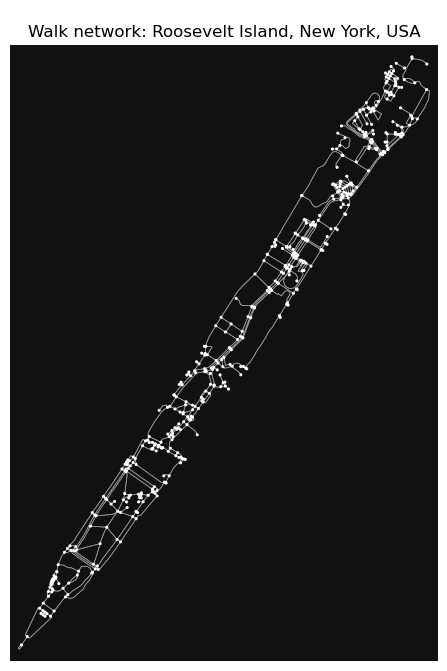

In [2]:
# Section 3: Define Study Area & Get Street Network Data
#
# Uses osmnx.graph_from_place() to download the street network for a given place from OpenStreetMap.
# network_type='walk' keeps only walkable ways (sidewalks, paths, residential streets, etc.)
# and excludes non-walkable roads like highways — important for studying "walking experience"
# under network distance.

# Study area: Roosevelt Island, New York, USA
# (An island neighborhood whose street network is bounded by water, which makes it a good case
#  for showing the difference between "network walking distance" and "straight-line distance";
#  swap this line for your own study area if you'd like a different one.)
PLACE_NAME = "Roosevelt Island, New York, USA"

# Download the walk network from OSM; returns a networkx MultiDiGraph
G = ox.graph_from_place(PLACE_NAME, network_type='walk')

# osmnx downloads the graph in lat/lon coordinates (EPSG:4326) by default.
# To make later distance calculations come out in meters (not degrees), we project
# to an appropriate metric coordinate system (UTM).
G = ox.project_graph(G)

# Basic network stats
print(f"Number of nodes (street intersections): {len(G.nodes)}")
print(f"Number of edges (street segments): {len(G.edges)}")

# Quick plot of the network to confirm the downloaded area looks right
fig, ax = ox.plot_graph(
    G, node_size=5, edge_linewidth=0.5, show=False, close=False
)
plt.title(f"Walk network: {PLACE_NAME}")
plt.show()


## Section 4: Define Nodes (Points of Interest)

In [3]:
# Section 4: Define the Nodes Whose Distances We're Measuring (Points of Interest)
#
# "Nodes" here means the specific locations relevant to your research question (e.g. bus stops,
# park entrances, shops), not the intersection nodes of the street network itself. We need to
# convert these locations to coordinates, then snap each one to its nearest street-network node
# (nearest_nodes) so that Section 6 can use networkx to compute network shortest paths.

# 8 representative locations on Roosevelt Island (coordinates from real OpenStreetMap POI data),
# spanning the island's north and south ends and the transit hubs/landmarks along the way — good
# for comparing "walking along the island" versus "straight-line distance."
# If these aren't the locations you want to study, just replace the list below with your own.
POI_LIST = [
    {"name": "Four Freedoms Park", "lat": 40.750694, "lon": -73.960446},  # memorial park at the south tip
    {"name": "Southpoint Park",    "lat": 40.752329, "lon": -73.958878},  # park in the south
    {"name": "Cornell Tech",       "lat": 40.754769, "lon": -73.956433},  # university campus
    {"name": "Tramway Station",    "lat": 40.757313, "lon": -73.954100},  # aerial tram station (transit link off the island)
    {"name": "Subway Station",     "lat": 40.759145, "lon": -73.953260},  # F train subway station (transit link off the island)
    {"name": "Blackwell House",    "lat": 40.760333, "lon": -73.951131},  # historic landmark in the middle of the island
    {"name": "Motorgate Garage",   "lat": 40.765026, "lon": -73.946319},  # parking garage / vehicle entrance in the north
    {"name": "Lighthouse Park",    "lat": 40.771974, "lon": -73.940785},  # lighthouse park at the north tip
]


def build_nodes_geodataframe(poi_list, graph):
    """Convert a list of locations (addresses or coordinates) into a GeoDataFrame,
    and label each point with the ID of its nearest street-network node (nearest_node).

    Args:
        poi_list: list of dict, each containing 'name' plus either
                   ('address') or ('lat', 'lon')
        graph: osmnx/networkx street network graph, already projected to a metric CRS

    Returns:
        GeoDataFrame with columns: name, geometry, nearest_node
    """
    records = []
    for poi in poi_list:
        if "address" in poi:
            # Use osmnx's geocode to convert the address into lat/lon coordinates
            lat, lon = ox.geocode(poi["address"])
        else:
            lat, lon = poi["lat"], poi["lon"]
        records.append({"name": poi["name"], "lat": lat, "lon": lon})

    gdf = gpd.GeoDataFrame(
        records,
        geometry=gpd.points_from_xy(
            [r["lon"] for r in records], [r["lat"] for r in records]
        ),
        crs="EPSG:4326",
    )

    # Project the points to the same metric CRS as the network so nearest-node matching is correct
    gdf = gdf.to_crs(graph.graph["crs"])

    # Use osmnx to find each point's nearest street-network node (intersection)
    gdf["nearest_node"] = ox.distance.nearest_nodes(graph, gdf.geometry.x, gdf.geometry.y)

    return gdf


In [4]:
# Call the function above to build the nodes table (an empty POI_LIST just gives an empty table,
# it won't error; re-run this cell after filling in POI_LIST)
nodes_gdf = build_nodes_geodataframe(POI_LIST, G)
nodes_gdf


,name,lat,lon,geometry,nearest_node
0,Four Freedoms Park,40.750694,-73.960446,POINT (587757.4 4511602.044),2487361071
1,Southpoint Park,40.752329,-73.958878,POINT (587887.617 4511785.11),5133221561
2,Cornell Tech,40.754769,-73.956433,POINT (588090.797 4512058.42),6323386781
3,Tramway Station,40.757313,-73.954100,POINT (588284.371 4512343.168),14018166596
4,Subway Station,40.759145,-73.953260,POINT (588352.85 4512547.379),8265114427
5,Blackwell House,40.760333,-73.951131,POINT (588530.981 4512681.402),8265114596
6,Motorgate Garage,40.765026,-73.946319,POINT (588930.894 4513207.227),5212861637
7,Lighthouse Park,40.771974,-73.940785,POINT (589388.661 4513984.134),7529976566


## Section 5: Compute Euclidean Distance Matrix

In [5]:
# Section 5: Compute Euclidean Distance Matrix (Straight-line Distance)
#
# Euclidean distance = the straight-line ("as the crow flies") distance between two points,
# ignoring the actual street layout. Since the coordinates are already projected to a metric
# CRS (UTM), the result of .distance() comes out in meters.

def compute_euclidean_distance_matrix(nodes_gdf):
    """Compute the pairwise Euclidean (straight-line) distance between all points in nodes_gdf.

    Args:
        nodes_gdf: GeoDataFrame, must already be projected to a metric CRS, with 'name' and
                   geometry columns

    Returns:
        DataFrame indexed/columned by location name, values are distances in meters
    """
    names = nodes_gdf["name"].tolist()
    n = len(nodes_gdf)
    dist_matrix = np.zeros((n, n))

    for i, geom_i in enumerate(nodes_gdf.geometry):
        # geopandas' .distance() can compute the distance from one point to an entire column of points at once
        dist_matrix[i, :] = nodes_gdf.geometry.distance(geom_i).values

    euclidean_df = pd.DataFrame(dist_matrix, index=names, columns=names)
    return euclidean_df


In [6]:
# Call the function above to build the Euclidean distance matrix
euclidean_dist_df = compute_euclidean_distance_matrix(nodes_gdf)
euclidean_dist_df.round(1)


,Four Freedoms Park,Southpoint Park,Cornell Tech,Tramway Station,Subway Station,Blackwell House,Motorgate Garage,Lighthouse Park
Four Freedoms Park,0.0,224.7,565.2,909.4,1117.2,1327.9,1988.4,2887.1
Southpoint Park,224.7,0.0,340.6,684.7,893.0,1103.3,1763.8,2662.5
Cornell Tech,565.2,340.6,0.0,344.3,554.8,762.8,1423.2,2322.2
Tramway Station,909.4,684.7,344.3,0.0,215.4,418.6,1079.2,1977.9
Subway Station,1117.2,893.0,554.8,215.4,0.0,222.9,877.2,1771.2
Blackwell House,1327.9,1103.3,762.8,418.6,222.9,0.0,660.6,1559.7
Motorgate Garage,1988.4,1763.8,1423.2,1079.2,877.2,660.6,0.0,901.7
Lighthouse Park,2887.1,2662.5,2322.2,1977.9,1771.2,1559.7,901.7,0.0


## Section 6: Compute Network Distance Matrix

In [7]:
# Section 6: Compute Network Distance Matrix (Shortest-path Distance)
#
# Network distance = the length of the shortest path walked along the actual street network
# (sidewalks, streets), using networkx.shortest_path_length() with each edge's 'length'
# attribute (meters) as the weight. This reflects "how far you'd actually have to walk"
# more realistically than Euclidean distance.

def compute_network_distance_matrix(graph, nodes_gdf):
    """Compute the pairwise shortest-path (network) distance between all points in nodes_gdf.

    Args:
        graph: networkx/osmnx street network graph (projected, edges have a 'length' attribute)
        nodes_gdf: GeoDataFrame with 'name' and 'nearest_node' columns (from Section 4)

    Returns:
        DataFrame indexed/columned by location name, values are network distances in meters
        (NaN if there is no reachable path between the two points)
    """
    names = nodes_gdf["name"].tolist()
    node_ids = nodes_gdf["nearest_node"].tolist()
    n = len(nodes_gdf)
    dist_matrix = np.full((n, n), np.nan)

    for i, source in enumerate(node_ids):
        # Compute shortest-path lengths from `source` to every other node in the graph at once —
        # more efficient than computing pair by pair
        lengths = nx.shortest_path_length(graph, source=source, weight="length")
        for j, target in enumerate(node_ids):
            if target in lengths:
                dist_matrix[i, j] = lengths[target]

    network_dist_df = pd.DataFrame(dist_matrix, index=names, columns=names)
    return network_dist_df


In [8]:
# Call the function above to build the network distance matrix (may take a few seconds to
# tens of seconds for larger node counts)
network_dist_df = compute_network_distance_matrix(G, nodes_gdf)
network_dist_df.round(1)


,Four Freedoms Park,Southpoint Park,Cornell Tech,Tramway Station,Subway Station,Blackwell House,Motorgate Garage,Lighthouse Park
Four Freedoms Park,0.0,218.0,621.9,1002.3,1164.0,1395.3,2059.4,3216.0
Southpoint Park,218.0,0.0,473.3,887.6,1049.4,1280.6,1944.8,3101.3
Cornell Tech,621.9,473.3,0.0,414.3,576.1,807.3,1471.5,2628.1
Tramway Station,1002.3,887.6,414.3,0.0,303.8,486.2,1150.4,2307.0
Subway Station,1164.0,1049.4,576.1,303.8,0.0,231.2,895.4,2052.0
Blackwell House,1395.3,1280.6,807.3,486.2,231.2,0.0,700.7,1857.2
Motorgate Garage,2059.4,1944.8,1471.5,1150.4,895.4,700.7,0.0,1162.6
Lighthouse Park,3216.0,3101.3,2628.1,2307.0,2052.0,1857.2,1162.6,0.0


## Section 7: Comparison Visualizations

### Section 7a: Map Comparison — Straight-line Path vs. Network Shortest Path

In [9]:
# Section 7a: Map Comparison — Straight-line vs. Network Shortest Path
#
# On the same map, draw the street network + nodes + for each node pair:
#   - the straight-line connection (Euclidean distance, blue dashed line)
#   - the shortest path along the network (network distance, green solid line)
# This makes the spatial difference between the two distance types easy to see (e.g. the
# network path detours noticeably around rivers, parks, or one-way blocks).

def plot_distance_comparison(graph, nodes_gdf, pairs, figsize=(10, 10)):
    """Overlay nodes on the street network basemap, and draw the straight-line and network
    shortest path for each specified node pair.

    Args:
        graph: street network graph (projected)
        nodes_gdf: node GeoDataFrame (includes nearest_node column)
        pairs: list of (name_a, name_b) tuples specifying which node pairs to compare
    """
    fig, ax = ox.plot_graph(
        graph, node_size=0, edge_linewidth=0.5, edge_color="gray",
        show=False, close=False, figsize=figsize,
    )

    # Plot all the study nodes
    nodes_gdf.plot(ax=ax, color="red", markersize=40, zorder=5)
    for _, row in nodes_gdf.iterrows():
        ax.annotate(row["name"], (row.geometry.x, row.geometry.y), fontsize=8)

    for idx, (name_a, name_b) in enumerate(pairs):
        row_a = nodes_gdf.loc[nodes_gdf["name"] == name_a].iloc[0]
        row_b = nodes_gdf.loc[nodes_gdf["name"] == name_b].iloc[0]

        # Straight line (Euclidean distance)
        ax.plot(
            [row_a.geometry.x, row_b.geometry.x],
            [row_a.geometry.y, row_b.geometry.y],
            linestyle="--", color="blue", linewidth=1.5,
            label="Euclidean (straight-line)" if idx == 0 else None,
        )

        # Network shortest path (along the streets): take the sequence of nodes the shortest
        # path passes through and connect their coordinates into a polyline
        route = nx.shortest_path(
            graph, row_a["nearest_node"], row_b["nearest_node"], weight="length"
        )
        route_coords = [(graph.nodes[n]["x"], graph.nodes[n]["y"]) for n in route]
        route_line = LineString(route_coords)
        gpd.GeoSeries([route_line], crs=nodes_gdf.crs).plot(
            ax=ax, color="green", linewidth=2.5,
            label="Network (shortest path)" if idx == 0 else None,
        )

    ax.legend()
    plt.title("Euclidean vs. Network Distance")
    plt.show()


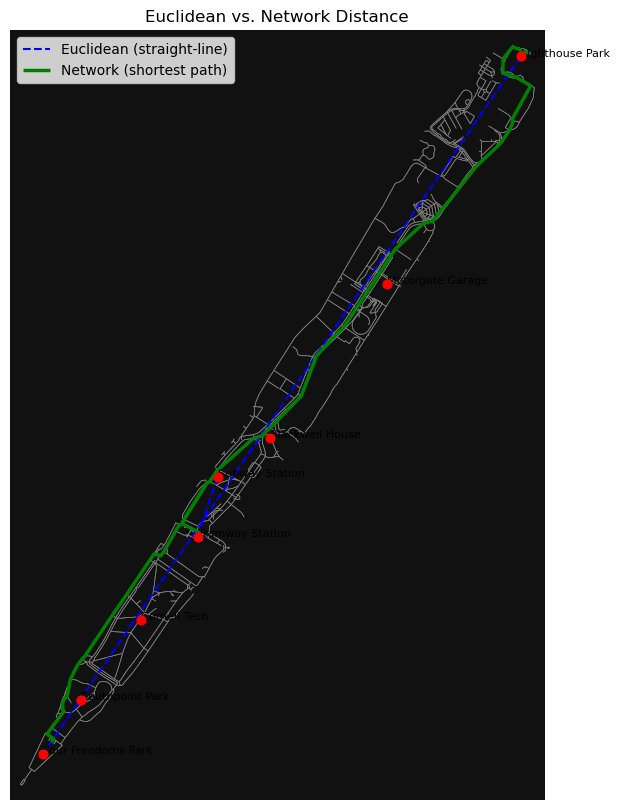

In [10]:
# Call the function above to draw the map comparison
pairs_to_plot = [
    ("Lighthouse Park", "Four Freedoms Park"),  # the island's northernmost vs. southernmost point, spanning nearly the whole island
    ("Subway Station", "Tramway Station"),      # two off-island transit hubs, close in a straight line but connected differently by the network
]
plot_distance_comparison(G, nodes_gdf, pairs_to_plot)


### Section 7b: Chart Comparison — Euclidean vs. Network Distance per Node Pair

In [11]:
# Section 7b: Chart Comparison — Euclidean vs. Network Distance (Bar Chart + Scatter Plot)
#
# For each node pair, compute ratio = network distance / Euclidean distance.
# The higher the ratio, the more "actually walking" detours compared to the straight-line
# distance for that pair — this is exactly the quantified version of the "experiential
# difference" this assignment asks you to discuss.

def build_comparison_table(euclidean_df, network_df):
    """Reshape the Euclidean and network distance matrices into a long table with
    one row per node pair, and compute ratio = network / euclidean, sorted from
    highest ratio to lowest.
    """
    records = []
    names = euclidean_df.index.tolist()
    for i, name_a in enumerate(names):
        for j, name_b in enumerate(names):
            if j <= i:
                continue  # skip duplicates (A-B and B-A are the same pair) and self-pairs
            eu = euclidean_df.loc[name_a, name_b]
            net = network_df.loc[name_a, name_b]
            ratio = net / eu if eu > 0 else np.nan
            records.append({
                "pair": f"{name_a} — {name_b}",
                "euclidean_m": eu,
                "network_m": net,
                "ratio": ratio,
            })
    return pd.DataFrame(records).sort_values("ratio", ascending=False).reset_index(drop=True)


In [12]:
# Call the function above to build the comparison table, sorted by ratio (network / euclidean) descending
comparison_df = build_comparison_table(euclidean_dist_df, network_dist_df)
comparison_df


,pair,euclidean_m,network_m,ratio
0,Tramway Station — Subway Station,215.387425,303.787655,1.410424
1,Southpoint Park — Cornell Tech,340.558995,473.270551,1.389687
2,Southpoint Park — Tramway Station,684.720078,887.591613,1.296284
3,Motorgate Garage — Lighthouse Park,901.739558,1162.633701,1.289323
4,Cornell Tech — Tramway Station,344.313700,414.321063,1.203324
5,Blackwell House — Lighthouse Park,1559.719633,1857.234313,1.190749
6,Southpoint Park — Subway Station,893.026194,1049.361421,1.175062
7,Tramway Station — Lighthouse Park,1977.934972,2306.999436,1.166368
8,Southpoint Park — Lighthouse Park,2662.487081,3101.334586,1.164826
9,Tramway Station — Blackwell House,418.591703,486.240985,1.161612


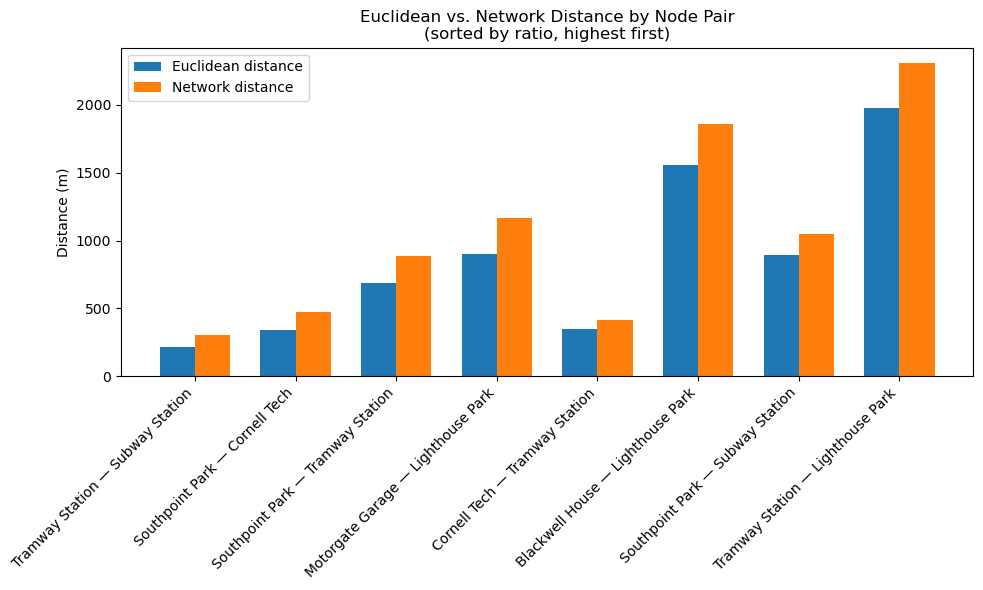

In [13]:
# --- Bar chart: Euclidean vs. network distance per node pair (sorted by ratio, largest gaps highlighted) ---

TOP_N = 8  # TODO: adjust to your number of nodes; only show the top-N pairs by ratio so the chart isn't too crowded
top_pairs = comparison_df.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top_pairs))
width = 0.35
ax.bar(x - width / 2, top_pairs["euclidean_m"], width, label="Euclidean distance")
ax.bar(x + width / 2, top_pairs["network_m"], width, label="Network distance")
ax.set_xticks(x)
ax.set_xticklabels(top_pairs["pair"], rotation=45, ha="right")
ax.set_ylabel("Distance (m)")
ax.set_title("Euclidean vs. Network Distance by Node Pair\n(sorted by ratio, highest first)")
ax.legend()
plt.tight_layout()
plt.show()


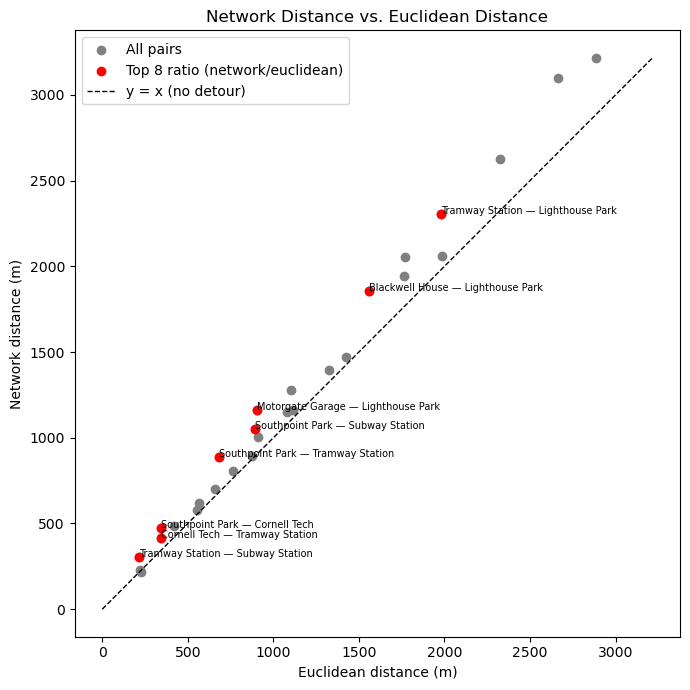

In [14]:
# --- Scatter plot: Euclidean vs. network distance, highlighting the pairs with the largest ratio ---

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(comparison_df["euclidean_m"], comparison_df["network_m"], color="gray", label="All pairs")

highlight = comparison_df.head(TOP_N)
ax.scatter(highlight["euclidean_m"], highlight["network_m"], color="red",
           label=f"Top {TOP_N} ratio (network/euclidean)")
for _, row in highlight.iterrows():
    ax.annotate(row["pair"], (row["euclidean_m"], row["network_m"]), fontsize=7)

# Draw a y = x reference line: if network distance equaled Euclidean distance, points would
# fall on this line; the farther a point sits above the line, the more the actual walk
# detours from the straight-line distance.
max_val = max(comparison_df["euclidean_m"].max(), comparison_df["network_m"].max())
ax.plot([0, max_val], [0, max_val], linestyle="--", color="black", linewidth=1, label="y = x (no detour)")

ax.set_xlabel("Euclidean distance (m)")
ax.set_ylabel("Network distance (m)")
ax.set_title("Network Distance vs. Euclidean Distance")
ax.legend()
plt.tight_layout()
plt.show()


## Reflection
[TODO: I will write here how Euclidean and network distance differ experientially,
and what this means for my research question]